In [ ]:
# --- Bibliotecas Estándar de Python ---
import os
import pickle
import random
from collections import Counter

# --- Bibliotecas de Ciencia de Datos y Gráficos ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- TensorFlow (Núcleo) ---
import tensorflow as tf

# --- Utilidades de Scikit-learn ---
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# --- TensorFlow Keras (Modelos y Aplicaciones) ---
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import MobileNetV2

# --- TensorFlow Keras (Capas) ---
# (Se incluyen las capas de Aumento de Datos de la celda 11)
from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    GlobalAveragePooling2D, RandomFlip,
    RandomRotation, RandomZoom
)

# --- TensorFlow Keras (Componentes de Entrenamiento) ---
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta
path_pokemon = '/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/pokemonDB_dataset.csv'

# Carga de datos
df = pd.read_csv(path_pokemon)

# Dividir los tipos múltiples en listas
listas_de_tipos = df['Type'].str.split(',')

conteo_tipos = Counter()

for lista in listas_de_tipos:
        # Creamos una lista limpia para cada Pokémon
        tipos_limpios = []
        for tipo in lista:
            # .strip() elimina espacios en blanco al inicio o final
            # ej. " Ice" -> "Ice"
            tipos_limpios.append(tipo.strip())

        # Actualizamos el conteo con los tipos limpios
        conteo_tipos.update(tipos_limpios)

In [ ]:
#---------------------------------------------------------------------------------------------------------------

if not os.path.exists("/content/pokemon1"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Images DB.zip" "/content/pokemon1.zip"
  print("¡Copia finalizada!")

  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon1.zip -d /content/pokemon1
  print("¡Dataset listo en /content/pokemon1!")
else:
  print("El dataset ya está en /content/pokemon1")

#---------------------------------------------------------------------------------------------------------------

if not os.path.exists("/content/pokemon2"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Dataset.zip" "/content/pokemon2.zip"
  print("¡Copia finalizada!")

  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon2.zip -d /content/pokemon2
  print("¡Dataset listo en /content/pokemon2!")
else:
  print("El dataset ya está en /content/pokemon2")

#---------------------------------------------------------------------------------------------------------------

if not os.path.exists("/content/pokemon3"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Fotos Pokemon1.zip" "/content/pokemon3.zip"
  print("¡Copia finalizada!")

  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon3.zip -d /content/pokemon3
  print("¡Dataset listo en /content/pokemon3!")
else:
  print("El dataset ya está en /content/pokemon3")

#---------------------------------------------------------------------------------------------------------------

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon1!
Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon2!
Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon3!


In [ ]:
def normalize_name(name):
    """
    Limpia un nombre de Pokémon para que coincida
    entre el CSV y los nombres de las carpetas.
    """
    if not isinstance(name, str):
        name = str(name)

    # Convertir a minúsculas PRIMERO
    name = name.lower()

    # 2. Quitar paréntesis y espacios
    name = name.replace("(", "").replace(")", "")

    # 3. Reemplazar caracteres especiales
    name = name.replace('♀', '-f')       # nidoran♀ -> nidoran-f
    name = name.replace('♂', '-m')       # nidoran♂ -> nidoran-m
    name = name.replace("'", "")       # farfetch'd -> farfetchd
    name = name.replace(".", "")       # mime jr. -> mimejr
    name = name.replace("_", "-")      # farfetch_d -> farfetch-d
    name = name.replace(" ", "")       # Mime Jr. -> mimejr (manejado por .lower() y replace)
    name = name.replace(":", "")       # Type: Null -> typenull

    return name

    print("Creando mapa de etiquetas normalizado...")

label_map = {}

for index, row in df.iterrows():

    # Obtener el nombre "sucio" del CSV
    nombre_pokemon_csv = row['Pokemon']

    # Manejar los casos especiales de Nidoran

    if "Nidoran♀ (female)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♀"
    elif "Nidoran♂ (male)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♂"
    else:
        # Si no es un caso especial, usar el nombre tal cual
        nombre_a_normalizar = nombre_pokemon_csv

    # 1. Normalizar el nombre (ya sea el original o el pre-limpiado)
    nombre_normalizado = normalize_name(nombre_a_normalizar)

    # 2. Obtener los tipos
    tipos_str = row['Type']
    lista_de_tipos = [tipo.strip() for tipo in tipos_str.split(',')]

    # 3. Guardar en el mapa con la clave normalizada
    if nombre_normalizado not in label_map:
        label_map[nombre_normalizado] = lista_de_tipos
    else:
        pass

print(f"--- Mapa de Etiquetas Creado. {len(label_map)} entradas únicas. ---")

# (Opcional) Verifica que los nombres clave se normalizaron bien
print("\nEjemplo del mapa (normalizado):")
print(f"'nidoran-f': {label_map.get('nidoran-f')}")
print(f"'nidoran-m': {label_map.get('nidoran-m')}")
print(f"'aegislashbladeforme': {label_map.get('aegislashbladeforme')}")
print(f"'farfetchd': {label_map.get('farfetchd')}")
print(f"'mimejr': {label_map.get('mimejr')}")

--- Mapa de Etiquetas Creado. 1215 entradas únicas. ---

Ejemplo del mapa (normalizado):
'nidoran-f': ['Poison']
'nidoran-m': ['Poison']
'aegislashbladeforme': ['Steel', 'Ghost']
'farfetchd': ['Normal', 'Flying']
'mimejr': ['Psychic', 'Fairy']


In [ ]:
carpeta_raiz = '/content/pokemon1'
X_rutas_imagenes = []
y_etiquetas = []

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# --- Verificación Rápida ---
if len(X_rutas_imagenes) > 0:
    print("Ejemplo de datos recopilados:")
    print(f"Ruta: {X_rutas_imagenes[0]}")
    print(f"Etiqueta: {y_etiquetas[0]}")
else:
    print("¡Advertencia! No se encontró ninguna imagen. Revisa la 'carpeta_raiz' y los nombres en el CSV.")

carpeta_raiz_nueva = r'/content/pokemon2'

print(f"\nIniciando exploración de la segunda fuente de datos: {carpeta_raiz_nueva}...")
imagenes_encontradas_antes = len(X_rutas_imagenes)

# Usamos os.walk para explorar la nueva ruta
for root, dirs, files in os.walk(carpeta_raiz_nueva):

    # 2. Filtrar: Buscamos carpetas que sean 'normal' y no 'shiny'
    #    Usamos .lower() para encontrar 'normal' o 'Normal'
    if os.path.sep + 'normal' in root.lower() and 'shiny' not in root.lower():

        # 3. Extraer el nombre del Pokémon
        try:
            partes_ruta = root.split(os.path.sep)

            # La carpeta 'normal' es la de [version]
            # La ruta es: ...\[nombrepokemon]\[generacion]\[juego]\[version]
            # Por lo tanto, el nombre está 3 niveles "arriba" de 'normal'

            # Encontramos el índice de la carpeta 'normal' (o 'Normal')
            idx_normal = -1
            for i, parte in enumerate(partes_ruta):
                if parte.lower() == 'normal':
                    idx_normal = i
                    break

            if idx_normal != -1 and idx_normal >= 3:
                # Extraemos el nombre: [idx_normal - 3]
                nombre_pokemon_folder = partes_ruta[idx_normal - 3]

                # 4. Normalizar el nombre (¡usando la misma función!)
                nombre_normalizado = normalize_name(nombre_pokemon_folder)

                # 5. Buscar en el mapa y añadir
                if nombre_normalizado in label_map:
                    for file_name in files:
                        # Nos aseguramos de tomar solo PNGs/JPGs (NO GIFs)
                        if file_name.endswith(('.png', '.jpg', '.jpeg')):
                            ruta_completa = os.path.join(root, file_name)
                            X_rutas_imagenes.append(ruta_completa)
                            y_etiquetas.append(label_map[nombre_normalizado])
                else:
                    # (Nos avisará si este nombre de carpeta no está en el CSV)
                    print(f"Advertencia (Fuente 2): Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada.")

        except Exception as e:
            print(f"Error procesando ruta {root}: {e}")

print("\n" + "-"*60)
print("Exploración de la segunda fuente de datos completada.")
nuevas_imagenes = len(X_rutas_imagenes) - imagenes_encontradas_antes
print(f"Imágenes añadidas desde esta fuente: {nuevas_imagenes}")
print(f"TOTAL de imágenes encontradas (ambas fuentes): {len(X_rutas_imagenes)}")
print(f"TOTAL de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")



carpeta_raiz = '/content/pokemon3'

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# --- Verificación Rápida ---
if len(X_rutas_imagenes) > 0:
    print("Ejemplo de datos recopilados:")
    print(f"Ruta: {X_rutas_imagenes[0]}")
    print(f"Etiqueta: {y_etiquetas[0]}")
else:
    print("¡Advertencia! No se encontró ninguna imagen. Revisa la 'carpeta_raiz' y los nombres en el CSV.")


Iniciando exploración.
Advertencia: Carpeta 'Pokemon Images DB' (normalizado a 'pokemonimagesdb') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Ultra Necrozma)' (normalizado a 'necrozmaultranecrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Greninja (Ash-Greninja)' (normalizado a 'greninjaash-greninja') no encontrada en el CSV.
Advertencia: Carpeta 'Galarian Farfetch_d' (normalizado a 'galarianfarfetch-d') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Confined)' (normalizado a 'hoopahoopaconfined') no encontrada en el CSV.
Advertencia: Carpeta 'Rotom (Frost Rotom)' (normalizado a 'rotomfrostrotom') no encontrada en el CSV.
Advertencia: Carpeta 'Rotom (Mow Rotom)' (normalizado a 'rotommowrotom') no encontrada en el CSV.
Advertencia: Carpeta 'Kyurem (Black Kyurem)' (normalizado a 'kyuremblackkyurem') no encontrada en el CSV.
Advertencia: Carpeta 'Sirfetch_d' (normalizado a 'sirfetch-d') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Unbound)'

In [ ]:
print("Iniciando binarización de las 15,068 etiquetas...")

mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y_etiquetas)

classes = mlb.classes_
num_classes = len(classes)

print("\n--- Binarizador de Etiquetas Creado ---")
print(f"Número total de clases (tipos) únicas: {num_classes}")
print(f"Clases encontradas: {classes}")

with open('mlb_binarizer.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("\nBinarizador guardado como 'mlb_binarizer.pkl'")

Iniciando binarización de las 15,068 etiquetas...

--- Binarizador de Etiquetas Creado ---
Número total de clases (tipos) únicas: 18
Clases encontradas: ['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']

Binarizador guardado como 'mlb_binarizer.pkl'


In [ ]:
print("\nDividiendo los 15,032 items en Train/Validation...")

X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_rutas_imagenes,
    y_binarized,
    test_size=0.2,
    random_state=42
)

print("\n--- Datos Divididos (Nuevos Totales) ---")
print(f"Imágenes de Entrenamiento (X_train_paths): {len(X_train_paths)}")
print(f"Etiquetas de Entrenamiento (y_train):     {len(y_train)}")
print(f"Imágenes de Validación (X_val_paths):   {len(X_val_paths)}")
print(f"Etiquetas de Validación (y_val):       {len(y_val)}")


Dividiendo los 15,032 items en Train/Validation...

--- Datos Divididos (Nuevos Totales) ---
Imágenes de Entrenamiento (X_train_paths): 12054
Etiquetas de Entrenamiento (y_train):     12054
Imágenes de Validación (X_val_paths):   3014
Etiquetas de Validación (y_val):       3014


Conteo de clases ANTES del sobremuestreo (en set de training):
  Bug: 1048
  Dark: 697
  Dragon: 666
  Electric: 733
  Fairy: 610
  Fighting: 768
  Fire: 929
  Flying: 1433
  Ghost: 571
  Grass: 1318
  Ground: 1044
  Ice: 571
  Normal: 1599
  Poison: 1143
  Psychic: 1197
  Rock: 919
  Steel: 688
  Water: 2058
Sobremuestreando 'Bug': Faltan 52 ejemplos (actual: 1048).
Sobremuestreando 'Dark': Faltan 403 ejemplos (actual: 697).
Sobremuestreando 'Dragon': Faltan 434 ejemplos (actual: 666).
Sobremuestreando 'Electric': Faltan 367 ejemplos (actual: 733).
Sobremuestreando 'Fairy': Faltan 490 ejemplos (actual: 610).
Sobremuestreando 'Fighting': Faltan 332 ejemplos (actual: 768).
Sobremuestreando 'Fire': Faltan 171 ejemplos (actual: 929).
Sobremuestreando 'Ghost': Faltan 529 ejemplos (actual: 571).
Sobremuestreando 'Ground': Faltan 56 ejemplos (actual: 1044).
Sobremuestreando 'Ice': Faltan 529 ejemplos (actual: 571).
Sobremuestreando 'Rock': Faltan 181 ejemplos (actual: 919).
Sobremuestreando 

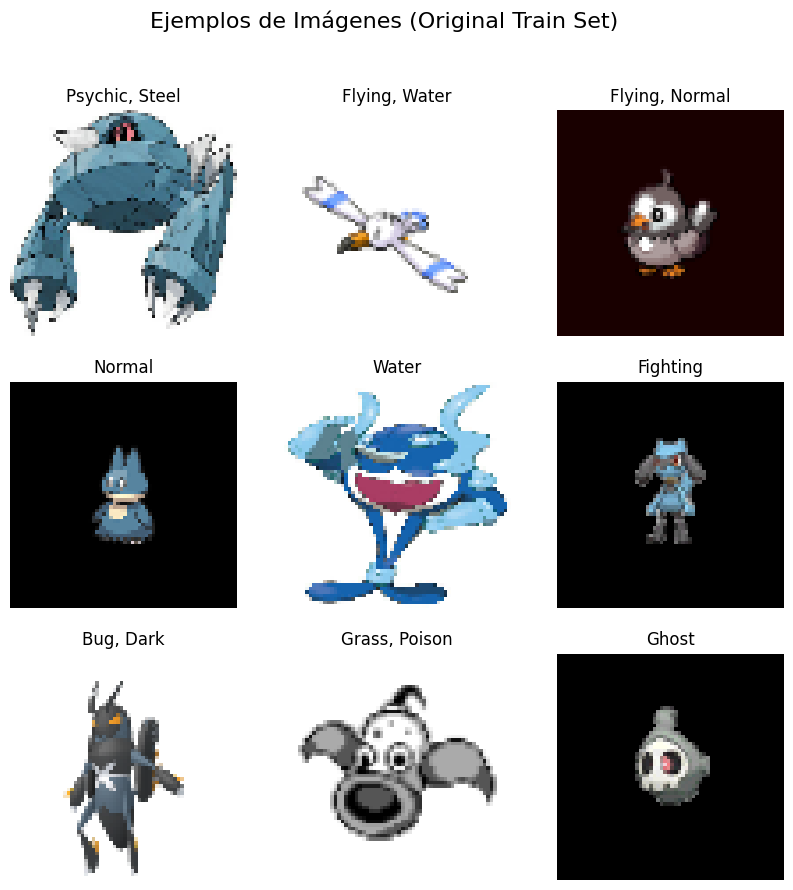

In [ ]:
target_count = 1100

# Calcular conteos de clases en el set de entrenamiento
class_counts = y_train.sum(axis=0)

print(f"Conteo de clases ANTES del sobremuestreo (en set de training):")
for i, class_name in enumerate(mlb.classes_):
    print(f"  {class_name}: {class_counts[i]}")

# Convertir a listas para añadir nuevos ejemplos
X_train_oversampled = list(X_train_paths)
y_train_oversampled = list(y_train)

# Iterar sobre cada índice de clase
for i in range(num_classes):
    current_count = class_counts[i]
    class_name = mlb.classes_[i]

    # Si la clase está por debajo del objetivo y no es 0
    if current_count < target_count and current_count > 0:
        num_to_add = target_count - current_count
        print(f"Sobremuestreando '{class_name}': Faltan {num_to_add} ejemplos (actual: {current_count}).")

        # Encontrar todos los paths y etiquetas que contienen esta clase
        # Usamos y_train (el array original) para encontrar los índices
        indices_this_class = [idx for idx, label in enumerate(y_train) if label[i] == 1]

        # Si no hay ninguno (improbable pero seguro), no podemos hacer nada
        if not indices_this_class:
            print(f"  Advertencia: No se encontraron ejemplos para '{class_name}' en y_train, no se puede sobremuestrear.")
            continue

        # Seleccionar 'num_to_add' de estos índices, CON REEMPLAZO
        indices_to_sample = random.choices(indices_this_class, k=num_to_add)

        # Añadir las muestras seleccionadas (paths y etiquetas) a nuestras nuevas listas
        for idx in indices_to_sample:
            X_train_oversampled.append(X_train_paths[idx])
            y_train_oversampled.append(y_train[idx])

print("\n--- Sobremuestreo Completado ---")
print(f"Total de imágenes de entrenamiento ANTES: {len(X_train_paths)}")
print(f"Total de imágenes de entrenamiento DESPUÉS: {len(X_train_oversampled)}")

# Convertir de nuevo a numpy array para el nuevo conteo y para tf.data
y_train_oversampled_np = np.array(y_train_oversampled)

print(f"\nConteo de clases DESPUÉS del sobremuestreo (en set de training):")
new_counts = y_train_oversampled_np.sum(axis=0)
for i, class_name in enumerate(mlb.classes_):
    print(f"  {class_name}: {new_counts[i]}")


# --- CELDA 10 (Original 9 - Definiciones y Carga) ---
IMG_SIZE = 64
NUM_CLASSES = 18 # Ya definido, pero bueno tenerlo
BATCH_SIZE = 16
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label, augment=False):
    image = tf.io.read_file(path)
    # expand_animations=False es CLAVE para manejar GIFs estáticos
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0  # Normalizar

    # Asegurarse de que la etiqueta sea del tipo correcto
    label = tf.cast(label, tf.float32)
    return image, label

# Visualización (ahora usa los datos de entrenamiento originales,
# la celda 16 usará los datos sobremuestreados)
print("\nMostrando ejemplos de imágenes (de la data original):")
plt.figure(figsize=(10, 10))
for i in range(min(9, len(X_train_paths))): # Usa los paths originales para este ejemplo
    ax = plt.subplot(3, 3, i + 1)
    img_path = X_train_paths[i]
    label = y_train[i]

    # Pre-carga para visualización (manejo de errores simple)
    try:
        image, _ = load_and_preprocess(img_path, label, augment=True)
        plt.imshow(image.numpy())
        tipos_pokemon = [classes[idx] for idx, val in enumerate(label) if val == 1]
        plt.title(", ".join(tipos_pokemon))
        plt.axis("off")
    except Exception as e:
        print(f"Error cargando imagen {img_path}: {e}")
        plt.title("Error de carga")
        plt.axis("off")

plt.suptitle("Ejemplos de Imágenes (Original Train Set)", fontsize=16)
plt.show()

In [ ]:
# --- Pipeline de Entrenamiento (MODIFICADO) ---
# Usamos las nuevas listas/arrays sobremuestreados
train_ds = tf.data.Dataset.from_tensor_slices((X_train_oversampled, y_train_oversampled_np))
train_ds = train_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=True), # 'augment=True' no se usa en load_preprocess, pero es conceptual
    num_parallel_calls=AUTOTUNE
)
# Usamos el nuevo tamaño para el buffer de shuffle
train_ds = train_ds.shuffle(buffer_size=len(X_train_oversampled))
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# --- Pipeline de Validación (Sin cambios) ---
val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val))
val_ds = val_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=False),
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Pipelines de Entrenamiento (train_ds - SOBREMUESTREADO) y Validación (val_ds) creados.")
print(f"   -> train_ds: {train_ds}")
print(f"   -> val_ds:   {val_ds}")

✅ Pipelines de Entrenamiento (train_ds - SOBREMUESTREADO) y Validación (val_ds) creados.
   -> train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.float32, name=None))>
   -> val_ds:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.float32, name=None))>


In [ ]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
], name='data_augmentation')

print("✅ Funciones de Transfer Learning (con MobileNetV2) listas.")

def create_transfer_model(input_shape, classes):
    # --- 1. Cargar la Base Pre-entrenada ---
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet', # ¡Aquí es donde falló la red!
        input_shape=input_shape
    )
    # --- 2. Congelar la Base (Inicialmente) ---
    base_model.trainable = False
    print(f"Base del modelo (MobileNetV2) cargada y congelada.")
    print(f"Parámetros de la base (congelados): {base_model.count_params()}")

    # --- 3. Añadir nuestra "Cabeza" (Head) ---
    inputs = Input(shape=input_shape, name='input_layer')
    x = data_augmentation(inputs) # Aplicar aumento aquí
    x = base_model(x, training=False) # Base en modo inferencia
    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dropout(0.5, name='head_dropout')(x)
    outputs = Dense(
        num_classes,
        activation='sigmoid', # Multi-label = sigmoid
        name='fc_pokemon'
    )(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

✅ Funciones de Transfer Learning (con MobileNetV2) listas.


In [ ]:
model, base_model = create_transfer_model(input_shape=IMG_SHAPE, classes=NUM_CLASSES)
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy', # Multi-label = binary_crossentropy
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])
early_stopping = EarlyStopping(
    monitor='recall',
    patience=20,
    verbose=1,
    restore_best_weights=True
)
callbacks_list = [early_stopping]
print("✅ Modelo MobileNetV2 compilado para FASE 1 (Entrenando la cabeza).")
model.summary()

/tmp/ipython-input-2992070051.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base del modelo (MobileNetV2) cargada y congelada.
Parámetros de la base (congelados): 2257984
✅ Modelo MobileNetV2 compilado para FASE 1 (Entrenando la cabeza).


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_pokemon (Dense)              │ (None, 18)             │        23,058 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,281,042 (8.70 MB)

 Trainable params: 23,058 (90.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("--- INICIANDO FASE 1: ENTRENANDO LA CABEZA (MobileNetV2) ---")
history_fase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=callbacks_list
)

print("\n--- INICIANDO FASE 2: FINE-TUNING (MobileNetV2) ---")
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Descongelando modelo base desde la capa {fine_tune_at}.")
model.compile(optimizer=Adam(learning_rate=1e-5), # Learning rate MUY bajo
              loss='binary_crossentropy',
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])

print("✅ Modelo re-compilado para FASE 2 (Fine-Tuning).")
model.summary()

history_fase2 = model.fit(
    train_ds,
    epochs=300,
    initial_epoch=history_fase1.epoch[-1],
    validation_data=val_ds,
    callbacks=callbacks_list
)
print("🚀 ¡Entrenamiento completado (Fase 1 y 2)!")

--- INICIANDO FASE 1: ENTRENANDO LA CABEZA (MobileNetV2) ---
Epoch 1/25
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 138s 105ms/step - accuracy: 0.8916 - loss: 0.3551 - precition: 0.1501 - recall: 0.0437 - val_accuracy: 0.9163 - val_loss: 0.2752 - val_precition: 0.4492 - val_recall: 0.0304
Epoch 2/25
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 140s 104ms/step - accuracy: 0.9112 - loss: 0.2912 - precition: 0.3740 - recall: 0.0477 - val_accuracy: 0.9178 - val_loss: 0.2688 - val_precition: 0.5815 - val_recall: 0.0403
Epoch 3/25
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 144s 118ms/step - accuracy: 0.9120 - loss: 0.2832 - precition: 0.4127 - recall: 0.0578 - val_accuracy: 0.9180 - val_loss: 0.2645 - val_precition: 0.5931 - val_recall: 0.0459
Epoch 4/25
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 131s 104ms/step - accuracy: 0.9126 - loss: 0.2807 - precition: 0.4346 - recall: 0.0624 - val_accuracy: 0.9181 - val_loss: 0.2632 - val_precition: 0.5882 - val_recall: 0.0488
Epoch 5/25
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 128s 101ms/step - accuracy: 0.912

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_pokemon (Dense)              │ (None, 18)             │        23,058 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,281,042 (8.70 MB)

 Trainable params: 1,884,498 (7.19 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 25/300
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 247s 202ms/step - accuracy: 0.8919 - loss: 0.6152 - precition: 0.1401 - recall: 0.0504 - val_accuracy: 0.9147 - val_loss: 0.4830 - val_precition: 0.4094 - val_recall: 0.0576
Epoch 26/300
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 252s 191ms/step - accuracy: 0.8891 - loss: 0.3819 - precition: 0.1563 - recall: 0.0670 - val_accuracy: 0.9135 - val_loss: 0.3431 - val_precition: 0.3767 - val_recall: 0.0610
Epoch 27/300
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 265s 194ms/step - accuracy: 0.9031 - loss: 0.3285 - precition: 0.2007 - recall: 0.0428 - val_accuracy: 0.9161 - val_loss: 0.2990 - val_precition: 0.4570 - val_recall: 0.0459
Epoch 28/300
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 227s 200ms/step - accuracy: 0.9094 - loss: 0.3091 - precition: 0.2661 - recall: 0.0312 - val_accuracy: 0.9171 - val_loss: 0.2827 - val_precition: 0.5212 - val_recall: 0.0355
Epoch 29/300
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 219s 191ms/step - accuracy: 0.9119 - loss: 0.3002 - precition: 0.3200 - recall: 0.02

In [ ]:
print("\nCell 16 (MODIFICADA): Generando cuadrícula de imágenes aleatorias del set de entrenamiento SOBREMUESTREADO...")
filas = 3
columnas = 3
num_imagenes = filas * columnas
fig, axes = plt.subplots(filas, columnas, figsize=(10, 10))

try:
    # MODIFICADO: Usar las listas sobremuestreadas
    indices_aleatorios = random.sample(range(len(X_train_oversampled)), k=num_imagenes)
except ValueError:
    print(f"Error: No tienes suficientes imágenes ({len(X_train_oversampled)}) para una cuadrícula de {num_imagenes}.")
    indices_aleatorios = []

if indices_aleatorios:
    for i, ax in enumerate(axes.flat):
        idx = indices_aleatorios[i]

        # MODIFICADO: Usar las listas sobremuestreadas
        img_path = X_train_oversampled[idx]
        label = y_train_oversampled_np[idx] # Usamos el array numpy

        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)

            # Formatear el título multi-label
            label_str_list = [mlb.classes_[j] for j, val in enumerate(label) if val == 1]
            label_str = ", ".join(label_str_list)
            if not label_str: label_str = "Sin Tipo"

            ax.set_title(label_str, fontsize=10)
            ax.axis('off')
        except FileNotFoundError:
            print(f"Error: No se pudo encontrar el archivo {img_path}")
            ax.set_title("Archivo no encontrado", fontsize=8)
            ax.axis('off')
        except Exception as e:
            # Captura errores de imágenes corruptas (ej. PNG con canal alfa malo)
            print(f"Error al cargar {img_path}: {e}")
            ax.set_title("Error de carga", fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    output_filename = "grid_imagenes_entrenamiento_oversampled.png"
    plt.savefig(output_filename)
    print(f"Cuadrícula de imágenes (sobrevemustreadas) guardada como: {output_filename}")
    plt.show()
else:
    print("No hay suficientes imágenes para generar la cuadrícula.")

In [ ]:
history_combined = {}
# Concatenar las métricas de la fase 1 y la fase 2
history_combined['loss'] = history_fase1.history['loss'] + history_fase2.history['loss']
history_combined['val_loss'] = history_fase1.history['val_loss'] + history_fase2.history['val_loss']
history_combined['accuracy'] = history_fase1.history['accuracy'] + history_fase2.history['accuracy']
# La 'val_accuracy' también debe ser concatenada
history_combined['val_accuracy'] = history_fase1.history['val_accuracy'] + history_fase2.history['val_accuracy']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_combined['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_combined['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida (Loss) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_combined['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history_combined['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión (Accuracy) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()

In [ ]:
print("Generando Matriz de Confusión (basada en 'argmax')...")
plt.figure(figsize=(15, 15))
y_pred_probs = model.predict(val_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)
y_true_indices = np.argmax(y_val, axis=1) # y_val ya es un array

cm = confusion_matrix(y_true_indices, y_pred_indices)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Mapa de Confusión - MobileNetV2 Pokémon', fontsize=16)
plt.ylabel('Etiqueta Real (True Label - argmax)', fontsize=12)
plt.xlabel('Etiqueta Predicha (Predicted Label - argmax)', fontsize=12)
plt.show()

In [ ]:
print("\nGenerando Reporte de Clasificación (Multi-label)...")
# 'sigmoid' nos da probabilidades (0.0 a 1.0) para cada clase.
# Decidimos que cualquier cosa por encima del 50% (0.5) es un "Sí".
y_pred = (y_pred_probs > 0.5).astype(int)

# 'y_val' son las etiquetas reales, 'y_pred' son las que dijo el modelo
print(classification_report(y_val, y_pred, target_names=classes, zero_division=0))